In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, GridSearchCV)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             roc_curve, auc)
try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "-q"])
    import shap

print("✅ Semua library berhasil diimport")
print(f"   SHAP version: {shap.__version__}")


✅ Semua library berhasil diimport
   SHAP version: 0.52.0


In [ ]:
from google.colab import files

uploaded = files.upload()  # Upload: dataset_B_05_2020.csv & Phishing_Legitimate_full.csv
file_names = list(uploaded.keys())

if len(file_names) < 2:
    raise ValueError(f"❌ Upload minimal 2 file CSV. Diterima: {len(file_names)}")

f_B = next((f for f in file_names if 'dataset_b' in f.lower() or '2020' in f.lower()), file_names[0])
f_A = next((f for f in file_names if 'legitimate' in f.lower() or 'full' in f.lower()), file_names[1])

print(f"📂 Dataset B : {f_B}  → 11.430 baris, 87 fitur")
print(f"📂 Dataset A : {f_A}  → 10.000 baris, 48 fitur")


Saving Phishing_Legitimate_full.csv to Phishing_Legitimate_full.csv
Saving dataset_B_05_2020.csv to dataset_B_05_2020.csv
📂 Dataset B : dataset_B_05_2020.csv  → 11.430 baris, 87 fitur
📂 Dataset A : Phishing_Legitimate_full.csv  → 10.000 baris, 48 fitur


In [ ]:
# ── Load ──────────────────────────────────────────────────────────────
df_A = pd.read_csv(f_A, engine='python', on_bad_lines='skip')
df_B = pd.read_csv(f_B, engine='python', on_bad_lines='skip')
df_A.columns = df_A.columns.str.strip()
df_B.columns = df_B.columns.str.strip()

# ── Label ──────────────────────────────────────────────────────────────
df_A['label'] = df_A['CLASS_LABEL'].astype(int)
df_B['label'] = (df_B['status'] == 'phishing').astype(int)

# ── Bersihkan Dataset B ────────────────────────────────────────────────
ZERO_VAR_B = ['nb_or', 'ratio_nullHyperlinks', 'ratio_intRedirection',
              'ratio_intErrors', 'submit_email', 'sfh']
df_B = df_B.drop(columns=['url', 'status'] + ZERO_VAR_B, errors='ignore')

# ── Bersihkan Dataset A ────────────────────────────────────────────────
df_A = df_A.drop(columns=['id', 'CLASS_LABEL'], errors='ignore')

# ── Gabung & isi NaN dengan 0 ─────────────────────────────────────────
df_merged = pd.concat([df_A.fillna(0), df_B.fillna(0)],
                      axis=0, ignore_index=True).fillna(0)

X = df_merged.drop('label', axis=1)
y = df_merged['label'].astype(int)

print(f"✅ Dataset A   : {df_A.shape[0]:,} baris | {df_A.shape[1]-1} fitur")
print(f"✅ Dataset B   : {df_B.shape[0]:,} baris | {df_B.shape[1]-1} fitur")
print(f"{'='*45}")
print(f"✅ Gabungan    : {X.shape[0]:,} baris | {X.shape[1]} fitur")
print(f"   Phishing   : {y.sum():,} ({y.mean():.1%})")
print(f"   Legitimate : {(y==0).sum():,} ({1-y.mean():.1%})")
print(f"\n✅ Sama dengan artikel pembanding: 21.430 URL")
print(f"   Fitur artikel ini  : {X.shape[1]} fitur")
print(f"   Fitur pembanding   : 26 fitur (setelah seleksi information gain)")


✅ Dataset A   : 10,000 baris | 48 fitur
✅ Dataset B   : 11,430 baris | 81 fitur
✅ Gabungan    : 21,430 baris | 129 fitur
   Phishing   : 10,715 (50.0%)
   Legitimate : 10,715 (50.0%)

✅ Sama dengan artikel pembanding: 21.430 URL
   Fitur artikel ini  : 129 fitur
   Fitur pembanding   : 26 fitur (setelah seleksi information gain)


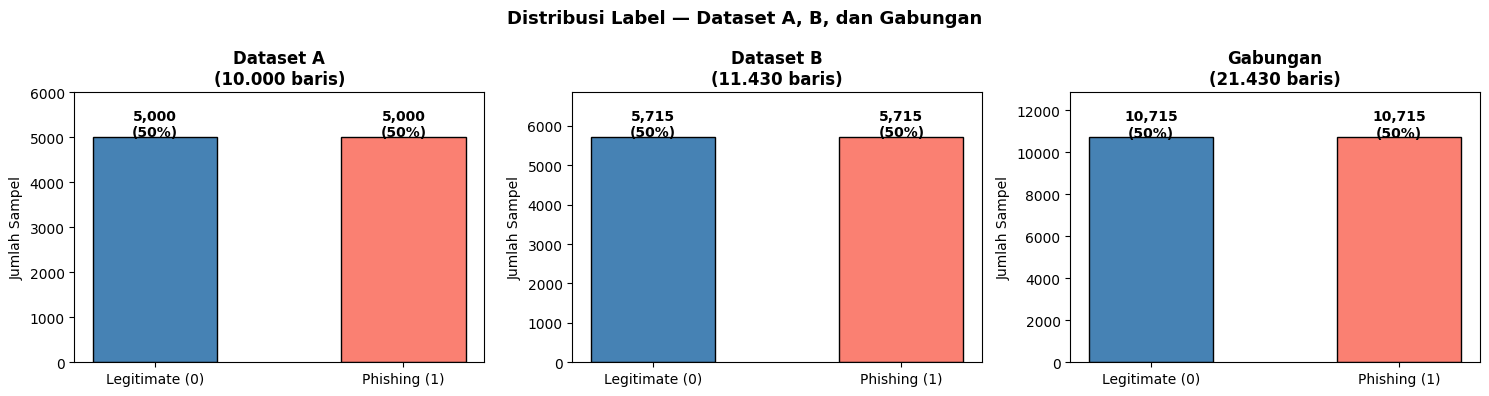

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, data_label, title in zip(axes,
    [df_A['label'], df_B['label'], y],
    ['Dataset A\n(10.000 baris)', 'Dataset B\n(11.430 baris)', 'Gabungan\n(21.430 baris)']):
    counts = data_label.value_counts().sort_index()
    bars = ax.bar(['Legitimate (0)', 'Phishing (1)'], counts.values,
                  color=['steelblue', 'salmon'], edgecolor='black', width=0.5)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f'{v:,}\n({v/len(data_label):.0%})',
                ha='center', fontweight='bold', fontsize=10)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Jumlah Sampel')
    ax.set_ylim(0, max(counts.values) * 1.2)

plt.suptitle('Distribusi Label — Dataset A, B, dan Gabungan',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


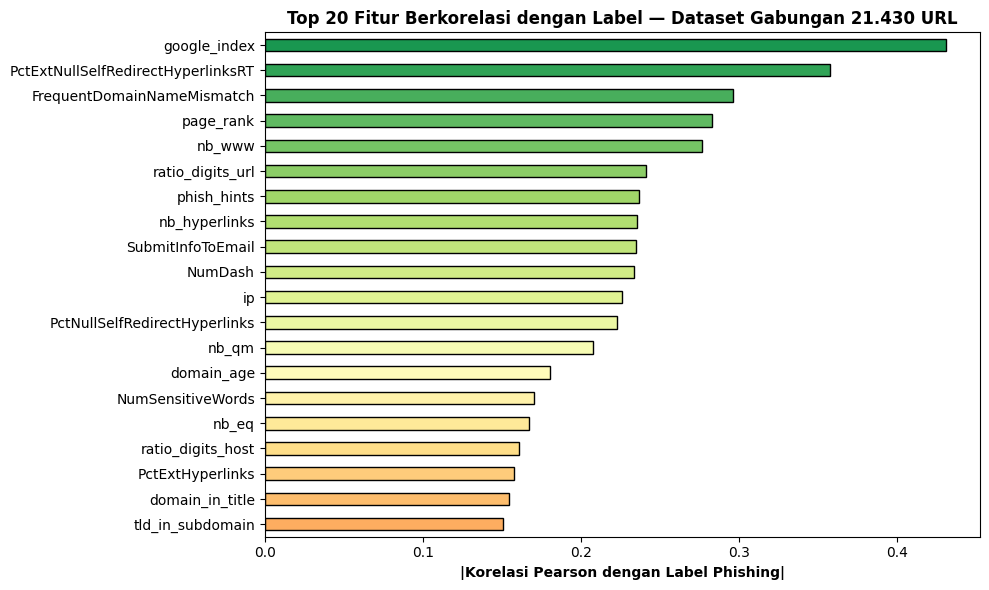

Top 10 fitur:
google_index                          0.431054
PctExtNullSelfRedirectHyperlinksRT    0.357757
FrequentDomainNameMismatch            0.296012
page_rank                             0.283328
nb_www                                0.276442
ratio_digits_url                      0.241145
phish_hints                           0.236729
nb_hyperlinks                         0.235647
SubmitInfoToEmail                     0.235206
NumDash                               0.233811


In [ ]:
# Top 20 fitur berkorelasi dengan label
corr = pd.concat([X, y.rename('label')], axis=1).corr()['label'].abs()
top20 = corr.drop('label').sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
colors_bar = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top20)))[::-1]
top20.plot(kind='barh', color=colors_bar, edgecolor='black')
plt.xlabel('|Korelasi Pearson dengan Label Phishing|', fontweight='bold')
plt.title('Top 20 Fitur Berkorelasi dengan Label — Dataset Gabungan 21.430 URL',
          fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 10 fitur:")
print(top20.head(10).to_string())


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set  : {X_train.shape[0]:,} baris ({X_train.shape[0]/len(X):.0%})")
print(f"Testing set   : {X_test.shape[0]:,} baris ({X_test.shape[0]/len(X):.0%})")
print(f"Jumlah fitur  : {X.shape[1]}")
print(f"\nProporsi phishing → Train: {y_train.mean():.2%} | Test: {y_test.mean():.2%}")


Training set  : 17,144 baris (80%)
Testing set   : 4,286 baris (20%)
Jumlah fitur  : 129

Proporsi phishing → Train: 50.00% | Test: 50.00%


In [ ]:
model = RandomForestClassifier(
    n_estimators=300,
    max_features='log2',     # konfigurasi terbaik dari eksperimen
    max_depth=None,          # pohon tumbuh penuh
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1                # gunakan semua core CPU
)

print("⏳ Training Random Forest pada dataset gabungan (21.430 URL, 129 fitur) ...")
model.fit(X_train, y_train)
print("✅ Training selesai")
print(f"   Jumlah pohon   : {model.n_estimators}")
print(f"   Max features   : {model.max_features}")
print(f"   Fitur dipakai  : {X.shape[1]}")


⏳ Training Random Forest pada dataset gabungan (21.430 URL, 129 fitur) ...
✅ Training selesai
   Jumlah pohon   : 300
   Max features   : log2
   Fitur dipakai  : 129


In [ ]:
y_pred  = model.predict(X_test)
y_prob  = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print("=" * 50)
print("  HASIL EVALUASI — RANDOM FOREST")
print("=" * 50)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {prec:.4f}  ({prec*100:.2f}%)")
print(f"  Recall    : {rec:.4f}  ({rec*100:.2f}%)")
print(f"  F1-Score  : {f1:.4f}  ({f1*100:.2f}%)")
print(f"  AUC-ROC   : {roc_auc:.4f}  ({roc_auc*100:.2f}%)")
print("=" * 50)
print()
print(classification_report(y_test, y_pred,
      target_names=['Legitimate', 'Phishing']))


  HASIL EVALUASI — RANDOM FOREST
  Accuracy  : 0.9748  (97.48%)
  Precision : 0.9779  (97.79%)
  Recall    : 0.9715  (97.15%)
  F1-Score  : 0.9747  (97.47%)
  AUC-ROC   : 0.9966  (99.66%)

              precision    recall  f1-score   support

  Legitimate       0.97      0.98      0.97      2143
    Phishing       0.98      0.97      0.97      2143

    accuracy                           0.97      4286
   macro avg       0.97      0.97      0.97      4286
weighted avg       0.97      0.97      0.97      4286



TP=2,082 | TN=2,096 | FP=47 | FN=61


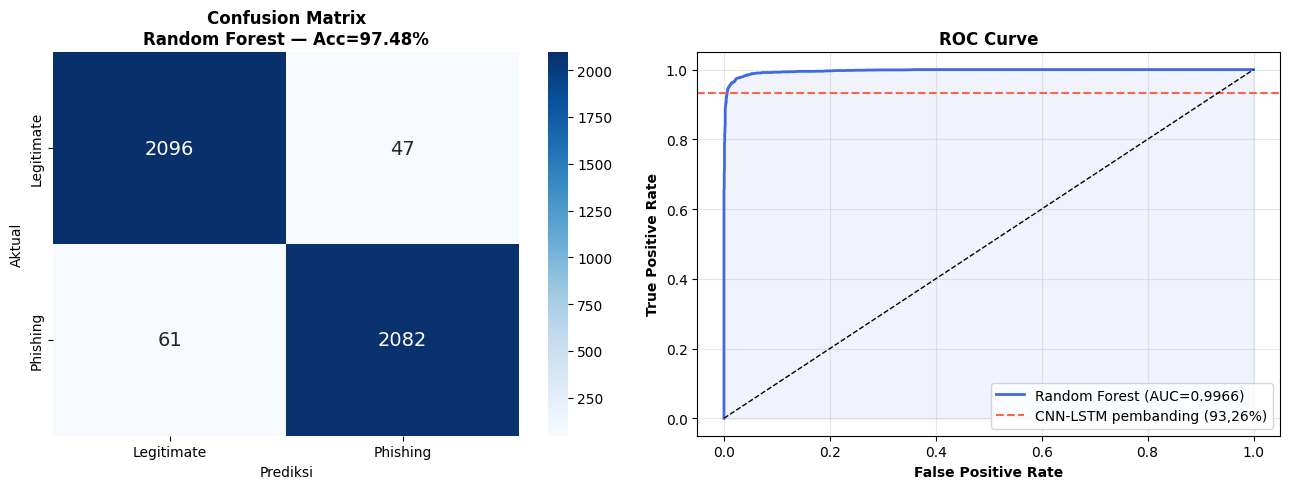

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Confusion Matrix ──────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'],
            annot_kws={'size': 14})
tn, fp, fn, tp = cm.ravel()
axes[0].set_title(f'Confusion Matrix\nRandom Forest — Acc={acc*100:.2f}%',
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('Prediksi'); axes[0].set_ylabel('Aktual')
print(f"TP={tp:,} | TN={tn:,} | FP={fp:,} | FN={fn:,}")

# ── ROC Curve ─────────────────────────────────────────────────────────
axes[1].plot(fpr, tpr, color='royalblue', lw=2,
             label=f'Random Forest (AUC={roc_auc:.4f})')
axes[1].fill_between(fpr, tpr, alpha=0.08, color='royalblue')
# Garis pembanding
axes[1].axhline(0.9326, color='tomato', linestyle='--', lw=1.5,
                label='CNN-LSTM pembanding (93,26%)')
axes[1].plot([0,1],[0,1],'k--',lw=1)
axes[1].set_xlabel('False Positive Rate', fontweight='bold')
axes[1].set_ylabel('True Positive Rate', fontweight='bold')
axes[1].set_title('ROC Curve', fontweight='bold', fontsize=12)
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Dataset  Akurasi  \
Sumber              Model                                                       
Alasmari et al. [1] CNN-LSTM                    21.430 URL, 26 fitur    93.26   
                    Logistic Regression         21.430 URL, 26 fitur    81.64   
                    Random Forest               21.430 URL, 26 fitur    88.29   
                    Naive Bayes                 21.430 URL, 26 fitur    74.73   
Artikel Ini         Random Forest (129 fitur)  21.430 URL, 129 fitur    97.48   

                                               Presisi  Recall     F1    AUC  
Sumber              Model                                                     
Alasmari et al. [1] CNN-LSTM                     93.26   93.28  93.26  98.28  
                    Logistic Regression          81.64   81.61  81.62  88.82  
                    Random Forest                88.51   88.37  88.28  96.30  
                    Naive Bayes                  74.76   74.68  74.69  82.61  
Artikel Ini         Random Forest (129 fitur)    97.79   97.15  97.47  99.66

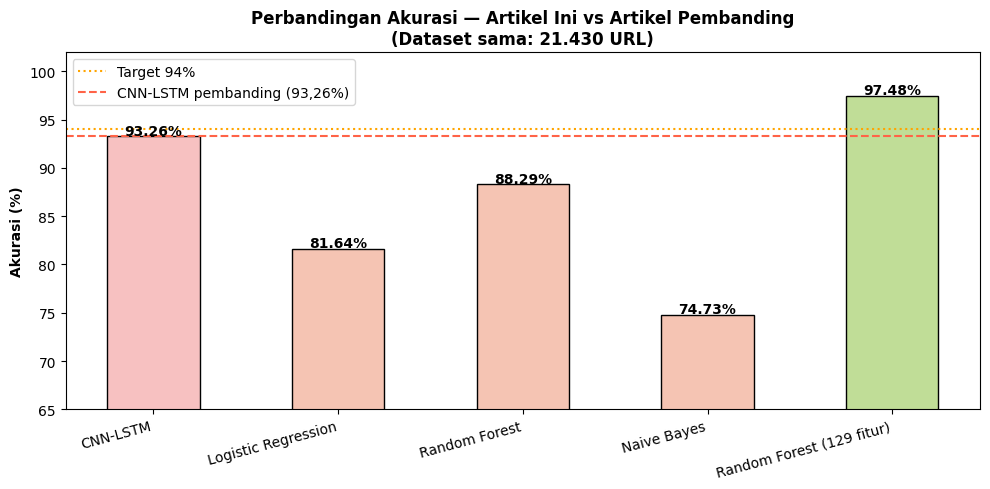


✅ Peningkatan vs CNN-LSTM pembanding : +4.22 poin persentase
✅ Peningkatan vs RF pembanding         : +9.19 poin persentase


In [ ]:
data_comp = {
    'Sumber'  : ['Alasmari et al. [1]']*4 + ['Artikel Ini'],
    'Model'   : ['CNN-LSTM', 'Logistic Regression', 'Random Forest', 'Naive Bayes',
                 'Random Forest (129 fitur)'],
    'Dataset' : ['21.430 URL, 26 fitur']*4 + ['21.430 URL, 129 fitur'],
    'Akurasi' : [93.26, 81.64, 88.29, 74.73, round(acc*100, 2)],
    'Presisi' : [93.26, 81.64, 88.51, 74.76, round(prec*100, 2)],
    'Recall'  : [93.28, 81.61, 88.37, 74.68, round(rec*100, 2)],
    'F1'      : [93.26, 81.62, 88.28, 74.69, round(f1*100, 2)],
    'AUC'     : [98.28, 88.82, 96.30, 82.61, round(roc_auc*100, 2)],
}
df_comp = pd.DataFrame(data_comp)
display(df_comp.set_index(['Sumber', 'Model']))

# Bar chart perbandingan akurasi
fig, ax = plt.subplots(figsize=(10, 5))
models_name = df_comp['Model']
accs = df_comp['Akurasi']
colors_comp = ['#F7C1C1','#F5C4B3','#F5C4B3','#F5C4B3', '#C0DD97']
bars = ax.bar(models_name, accs, color=colors_comp, edgecolor='black', width=0.5)
ax.axhline(94, color='orange', linestyle=':', lw=1.5, label='Target 94%')
ax.axhline(93.26, color='tomato', linestyle='--', lw=1.5,
           label='CNN-LSTM pembanding (93,26%)')
for bar, v in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{v:.2f}%', ha='center', fontweight='bold', fontsize=10)
ax.set_ylabel('Akurasi (%)', fontweight='bold')
ax.set_title('Perbandingan Akurasi — Artikel Ini vs Artikel Pembanding\n(Dataset sama: 21.430 URL)',
             fontweight='bold', fontsize=12)
ax.set_ylim(65, 102)
ax.legend(fontsize=10)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

print(f"\n✅ Peningkatan vs CNN-LSTM pembanding : +{(acc*100 - 93.26):.2f} poin persentase")
print(f"✅ Peningkatan vs RF pembanding         : +{(acc*100 - 88.29):.2f} poin persentase")


⏳ Menjalankan Cross-Validation 10-Fold ...

✅ CV-10 Accuracy : 0.9748 ± 0.0034
✅ CV-10 F1-Score  : 0.9747 ± 0.0035
✅ CV-10 AUC-ROC   : 0.9966 ± 0.0009


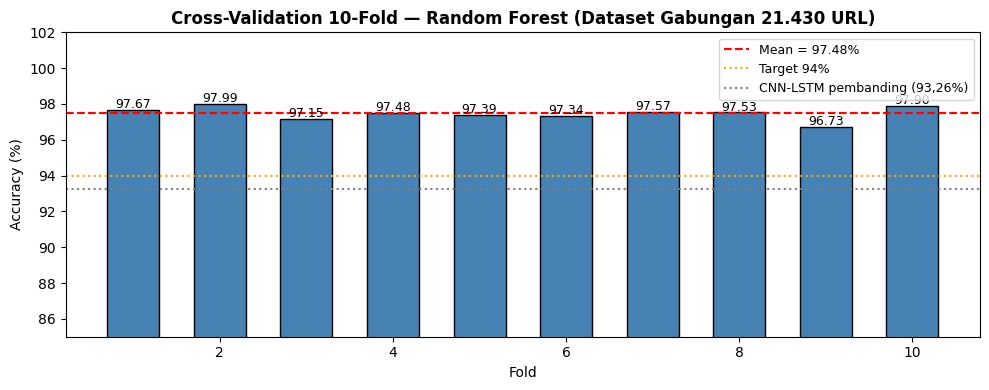

In [ ]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
print("⏳ Menjalankan Cross-Validation 10-Fold ...")

cv_acc = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
cv_f1  = cross_val_score(model, X, y, cv=cv, scoring='f1', n_jobs=-1)
cv_auc = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"\n✅ CV-10 Accuracy : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}")
print(f"✅ CV-10 F1-Score  : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print(f"✅ CV-10 AUC-ROC   : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
x_pos = range(1, 11)
bars = ax.bar(x_pos, cv_acc * 100, color='steelblue', edgecolor='black', width=0.6)
ax.axhline(cv_acc.mean()*100, color='red', linestyle='--', lw=1.5,
           label=f'Mean = {cv_acc.mean()*100:.2f}%')
ax.axhline(94, color='orange', linestyle=':', lw=1.5, label='Target 94%')
ax.axhline(93.26, color='gray', linestyle=':', lw=1.5,
           label='CNN-LSTM pembanding (93,26%)')
for bar, v in zip(bars, cv_acc):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{v*100:.2f}', ha='center', fontsize=9)
ax.set_xlabel('Fold'); ax.set_ylabel('Accuracy (%)')
ax.set_title('Cross-Validation 10-Fold — Random Forest (Dataset Gabungan 21.430 URL)',
             fontweight='bold')
ax.legend(fontsize=9); ax.set_ylim(85, 102)
plt.tight_layout(); plt.show()


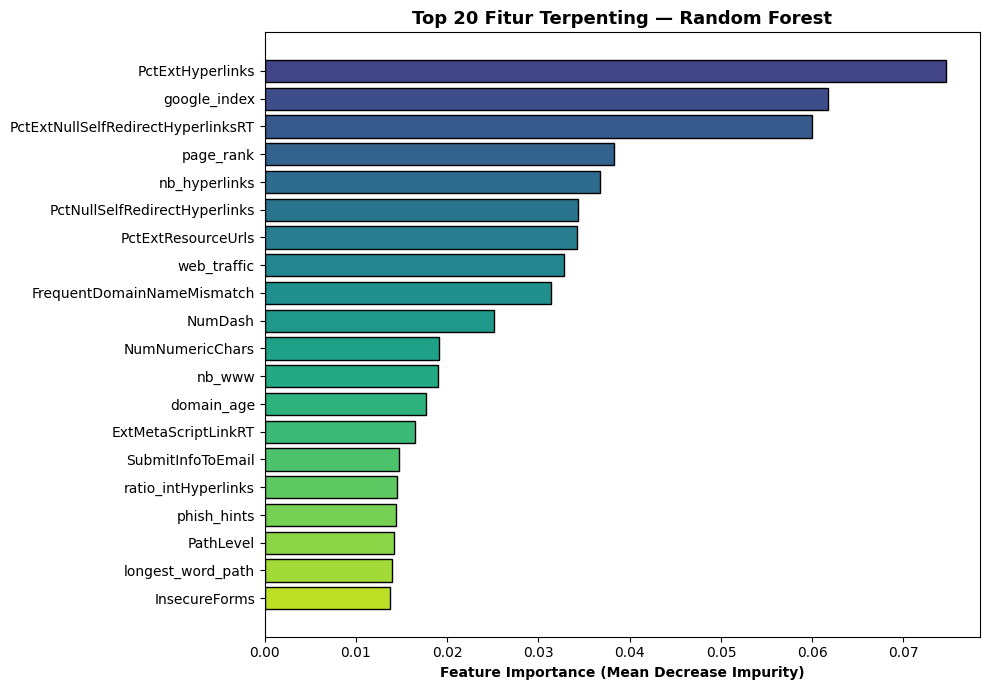


Top 15 Fitur:
                             Fitur  Importance
                  PctExtHyperlinks    0.074659
                      google_index    0.061709
PctExtNullSelfRedirectHyperlinksRT    0.059976
                         page_rank    0.038289
                     nb_hyperlinks    0.036739
     PctNullSelfRedirectHyperlinks    0.034344
                PctExtResourceUrls    0.034267
                       web_traffic    0.032848
        FrequentDomainNameMismatch    0.031417
                           NumDash    0.025172
                   NumNumericChars    0.019146
                            nb_www    0.018955
                        domain_age    0.017685
               ExtMetaScriptLinkRT    0.016451
                 SubmitInfoToEmail    0.014725


In [ ]:
feat_imp = pd.DataFrame({
    'Fitur'     : X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

# Top 20
fig, ax = plt.subplots(figsize=(10, 7))
top = feat_imp.head(20)
colors_fi = plt.cm.viridis(np.linspace(0.2, 0.9, len(top)))
ax.barh(top['Fitur'], top['Importance'], color=colors_fi, edgecolor='black')
ax.set_xlabel('Feature Importance (Mean Decrease Impurity)', fontweight='bold')
ax.set_title('Top 20 Fitur Terpenting — Random Forest', fontweight='bold', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 15 Fitur:")
print(feat_imp.head(15).to_string(index=False))


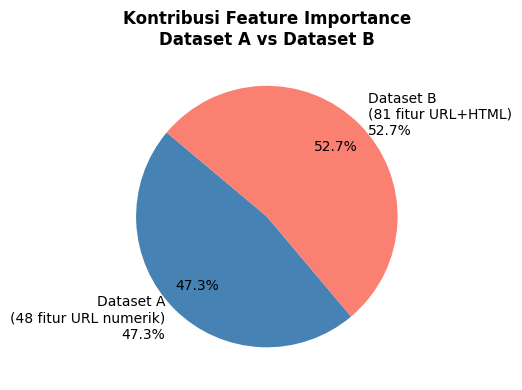

In [ ]:
# Pie chart: kontribusi fitur Dataset A vs Dataset B
cols_A = set(df_A.columns) - {'label'}
cols_B = set(df_B.columns) - {'label'}

imp_A = feat_imp[feat_imp['Fitur'].isin(cols_A)]['Importance'].sum()
imp_B = feat_imp[feat_imp['Fitur'].isin(cols_B)]['Importance'].sum()

fig, ax = plt.subplots(figsize=(6, 4))
ax.pie([imp_A, imp_B],
       labels=[f'Dataset A\n(48 fitur URL numerik)\n{imp_A:.1%}',
               f'Dataset B\n(81 fitur URL+HTML)\n{imp_B:.1%}'],
       colors=['steelblue', 'salmon'],
       autopct='%1.1f%%', startangle=140, pctdistance=0.75)
ax.set_title('Kontribusi Feature Importance\nDataset A vs Dataset B',
             fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
print(f"⚙️  Menghitung SHAP values untuk {len(X_test):,} sampel (seluruh test set) ...")
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Kompatibel format SHAP lama (list) dan baru (3D array)
if isinstance(shap_values, list):
    sv = shap_values[1]
elif hasattr(shap_values, 'ndim') and shap_values.ndim == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

ev = explainer.expected_value
ev_scalar = float(ev[1]) if hasattr(ev, '__len__') and len(ev) > 1 else float(ev)

print(f"✅ SHAP selesai | shape: {sv.shape}")


⚙️  Menghitung SHAP values untuk 4,286 sampel (seluruh test set) ...
✅ SHAP selesai | shape: (4286, 129)


📊 SHAP Summary Plot — Global Feature Impact


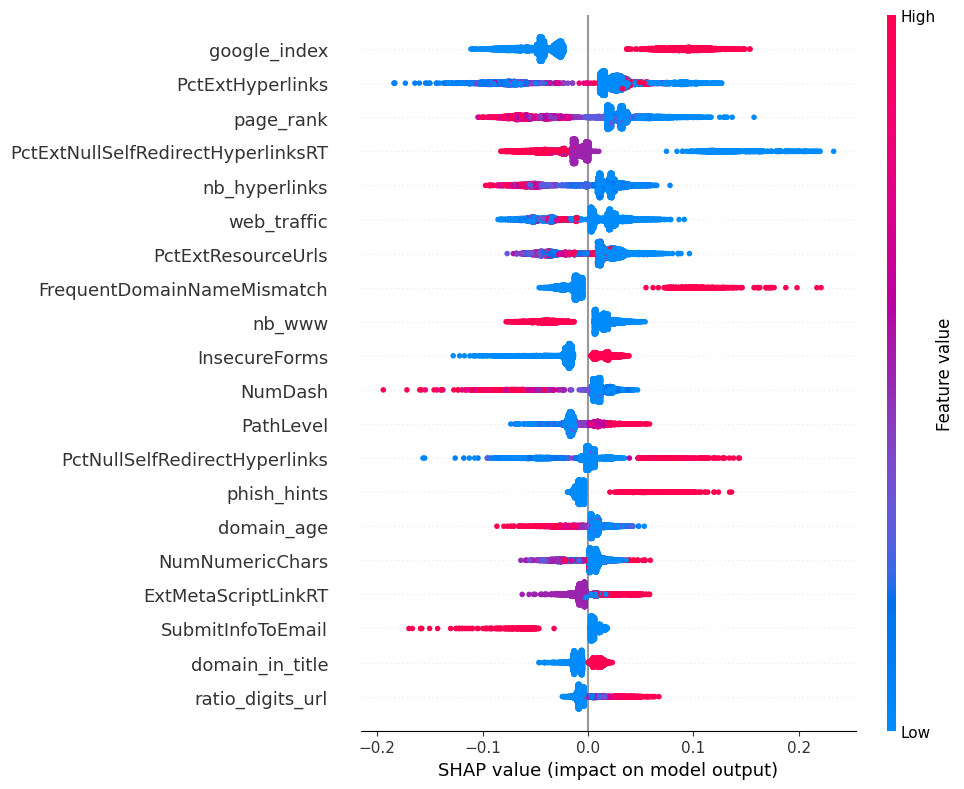

In [ ]:
# ── SHAP Summary Plot (Beeswarm) ─────────────────────────────────────
print("📊 SHAP Summary Plot — Global Feature Impact")
shap.summary_plot(sv, X_test, plot_type='dot',
                  max_display=20, show=True, plot_size=(10, 8))


📊 SHAP Bar Plot — Rata-rata Kontribusi Fitur


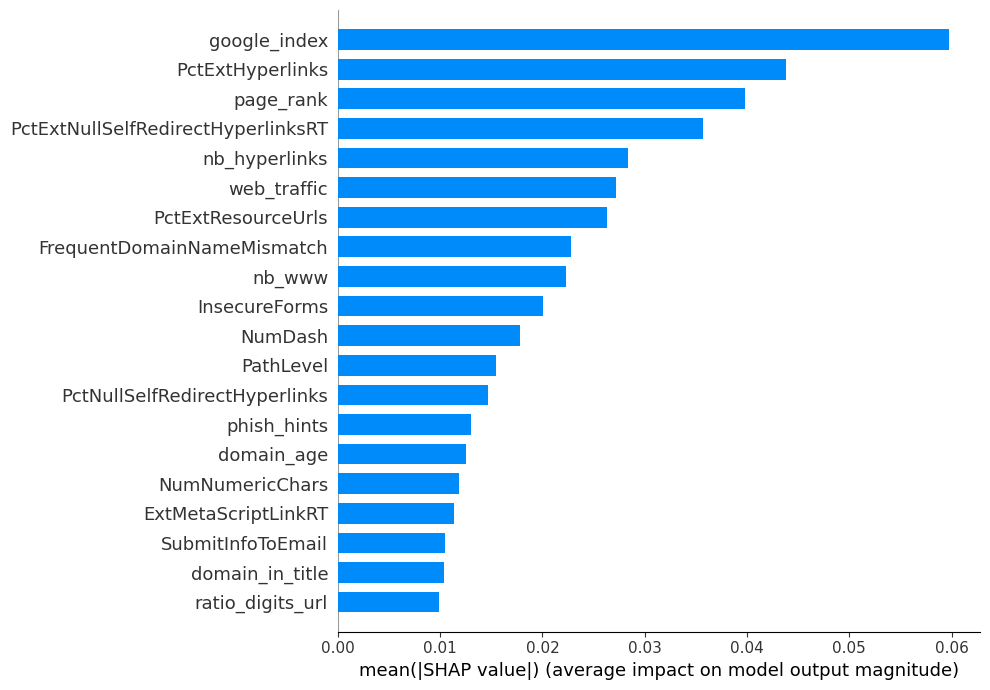

In [ ]:
# ── SHAP Bar Plot ─────────────────────────────────────────────────────
print("📊 SHAP Bar Plot — Rata-rata Kontribusi Fitur")
shap.summary_plot(sv, X_test, plot_type='bar',
                  max_display=20, show=True, plot_size=(10, 7))


📊 SHAP Dependence Plot — fitur 'PctExtHyperlinks'


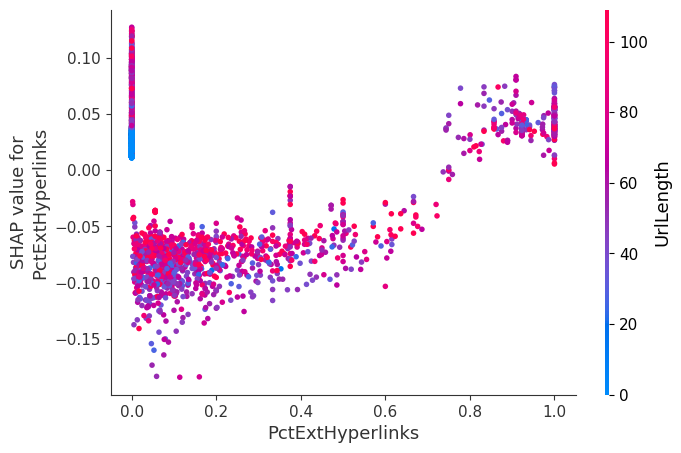

In [ ]:
# ── SHAP Dependence Plot — fitur terpenting ───────────────────────────
top_feat = feat_imp['Fitur'].iloc[0]
print(f"📊 SHAP Dependence Plot — fitur '{top_feat}'")
shap.dependence_plot(top_feat, sv, X_test, show=True)


📊 Force Plot — Sampel PHISHING (index 0)


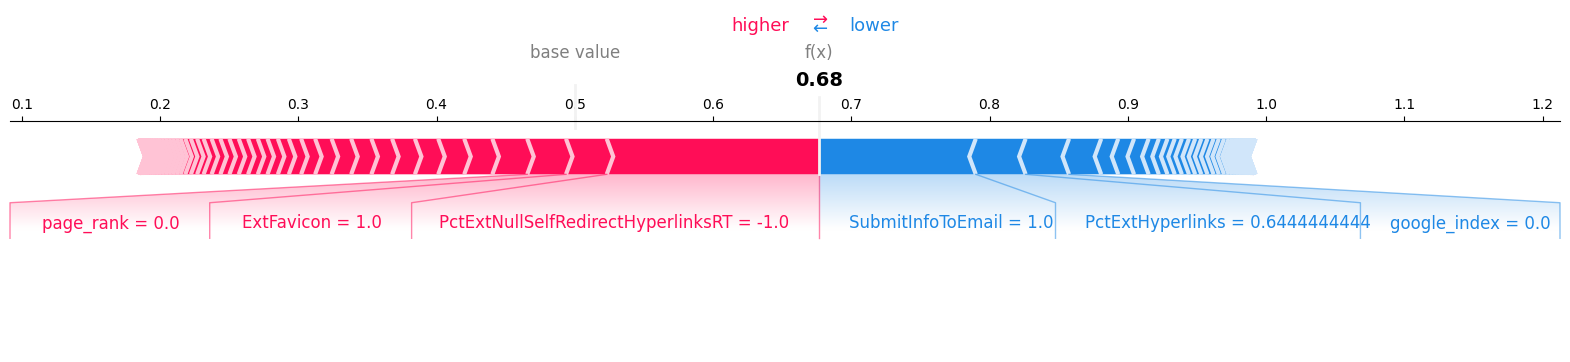

In [ ]:
# ── SHAP Force Plot — sampel PHISHING ────────────────────────────────
phishing_idx = np.where(y_test.values == 1)[0][0]
print(f"📊 Force Plot — Sampel PHISHING (index {phishing_idx})")
shap.initjs()
shap.plots.force(ev_scalar, sv[phishing_idx],
                 X_test.iloc[phishing_idx], matplotlib=True)


📊 Force Plot — Sampel LEGITIMATE (index 4)


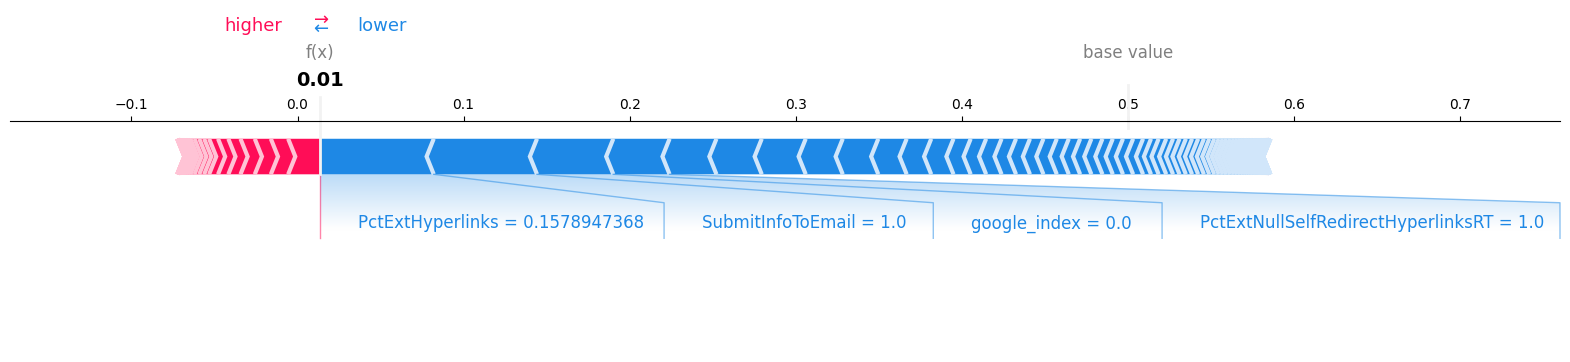

In [ ]:
# ── SHAP Force Plot — sampel LEGITIMATE ──────────────────────────────
benign_idx = np.where(y_test.values == 0)[0][0]
print(f"📊 Force Plot — Sampel LEGITIMATE (index {benign_idx})")
shap.plots.force(ev_scalar, sv[benign_idx],
                 X_test.iloc[benign_idx], matplotlib=True)


In [ ]:
print("=" * 60)
print("  RINGKASAN HASIL — RANDOM FOREST")
print("  Dataset: 21.430 URL (sama dengan artikel pembanding)")
print("=" * 60)
print(f"  Akurasi   : {acc*100:.2f}%")
print(f"  Presisi   : {prec*100:.2f}%")
print(f"  Recall    : {rec*100:.2f}%")
print(f"  F1-Score  : {f1*100:.2f}%")
print(f"  AUC-ROC   : {roc_auc*100:.2f}%")
print(f"  CV-10 Acc : {cv_acc.mean()*100:.2f}% ± {cv_acc.std()*100:.2f}%")
print("=" * 60)
print(f"\n  PERBANDINGAN vs ARTIKEL PEMBANDING [1]:")
print(f"  CNN-LSTM     : 93,26%  →  Artikel ini: {acc*100:.2f}%  (+{acc*100-93.26:.2f}pp) ✅")
print(f"  Random Forest: 88,29%  →  Artikel ini: {acc*100:.2f}%  (+{acc*100-88.29:.2f}pp) ✅")
print(f"\n  Kunci peningkatan: 129 fitur vs 26 fitur (artikel pembanding)")
print(f"  Model       : Random Forest (murni, tanpa XGBoost)")
print("=" * 60)


  RINGKASAN HASIL — RANDOM FOREST
  Dataset: 21.430 URL (sama dengan artikel pembanding)
  Akurasi   : 97.48%
  Presisi   : 97.79%
  Recall    : 97.15%
  F1-Score  : 97.47%
  AUC-ROC   : 99.66%
  CV-10 Acc : 97.48% ± 0.34%

  PERBANDINGAN vs ARTIKEL PEMBANDING [1]:
  CNN-LSTM     : 93,26%  →  Artikel ini: 97.48%  (+4.22pp) ✅
  Random Forest: 88,29%  →  Artikel ini: 97.48%  (+9.19pp) ✅

  Kunci peningkatan: 129 fitur vs 26 fitur (artikel pembanding)
  Model       : Random Forest (murni, tanpa XGBoost)


In [ ]:
import pickle

# Simpan model
with open('rf_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('feature_names.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

feat_imp.to_csv('feature_importance.csv', index=False)

# Download ke komputer
from google.colab import files
files.download('rf_model.pkl')
files.download('feature_names.pkl')
files.download('feature_importance.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>